In [1]:
import numpy as np
import os
import cv2 as cv
from ultralytics import YOLO # pip install ultralytics==8.2.10
from matplotlib import pyplot as plt
import shutil

In [2]:
# Crop left over items and illuminate the background
def hough_circling_coin(image):
    h, w, _ = image.shape
    offset = 50
    min_radius = (min(h, w)) // 2 - offset
    max_radius = (max(h, w) ) // 2 + offset
#     print(image.shape, min_radius, max_radius)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    blurred = cv.GaussianBlur(gray, (9, 9), 2)
    circles = cv.HoughCircles(
        blurred,
        cv.HOUGH_GRADIENT,
        dp=1.2,
        minDist=50,  # Minimum distance between detected circles
        param1=50,   # Higher threshold for Canny edge detection
        param2=50,   # Accumulator threshold for circle detection
        minRadius=min_radius, #250,  # Minimum radius of the coin
        maxRadius=max_radius    # Maximum radius (0 means no limit)
    )
    if circles is not None:
        circles_int = np.round(circles[0, :]).astype("int")
        x, y, r = circles_int[0] # Extract the first detected circle (assuming it's the coin)
        mask = np.zeros_like(gray)
        cv.circle(mask, (x, y), r, 255, -1)
        masked_coin = cv.bitwise_and(image, image, mask=mask)
        x1, y1, x2, y2 = x - r, y - r, x + r, y + r
        cropped_coin = masked_coin[abs(y1):y2, abs(x1):x2]
        return cropped_coin
    else:
        return False

In [3]:
# coin detection
def coin_extraction(img_path, out_pth):
    model = YOLO("best.pt")  
    result = model(img_path, save_crop=True,  project=out_pth)

    # coin presence checking
    coin_detect = result[0].boxes.cls.numpy()
#     print(coin_detect, len(coin_detect))
    if len(coin_detect) == 1:
        print("coin detected")
        crop_path = f'{out_pth}predict/crops/coin'
        crops = os.listdir(crop_path)
        image = cv.imread(os.path.join(crop_path, crops[0]))
#         print(image.shape)
        cropped_coin = hough_circling_coin(image)
        if  type(cropped_coin) is bool:
            return 'No coin'
            #plt.imshow(image[...,::-1], cmap='gray')
        else:
            return cropped_coin

    elif len(coin_detect) > 1:
        return "Multiple coins detected"
    else:
        return "No coin"


image 1/1 C:\Users\Temporary\Desktop\coins-testbed\Final\Code\..\test_folder2\images\000D2A9D-r.jpg: 640x640 1 coin, 268.0ms
Speed: 7.0ms preprocess, 268.0ms inference, 283.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to ..\test_folder2\predict
coin detected


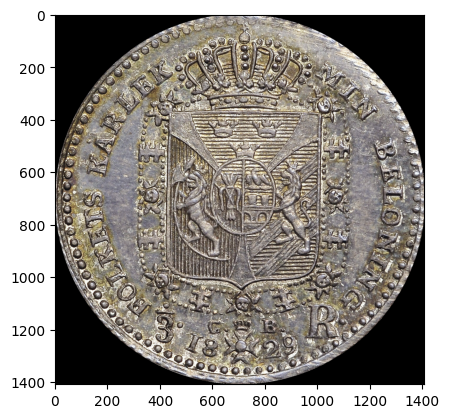

In [4]:
path = "../test_folder2/images"
img_list = os.listdir(path)
out_pth = '../test_folder2/'
cropped_coin = coin_extraction(img_path=os.path.join(path, img_list[10]), out_pth=out_pth)
if  type(cropped_coin) is str:
    print(cropped_coin)
else:
    plt.imshow(cropped_coin[...,::-1], cmap='gray')

# this will remove the directory and all its contents; this is important otherwise the next run will create another
# directory predict2, preditct3, etc. 
shutil.rmtree(f'{out_pth}predict')